# 1. Introduction

Urban mobility is a key component of modern cities, influencing economic activity, accessibility, and daily life. In large metropolitan areas such as New York City, taxi services play an important role in transporting millions of passengers every year.

The dataset used in this project contains detailed information about taxi trips, including pickup and dropoff times, trip distance, passenger count, payment information, and the geographic zones where trips start and end. These data are publicly available through the NYC Taxi and Limousine Commission, which regulates taxi services in the city.

The main goal of this analysis is to explore taxi trip patterns and identify insights related to urban mobility in New York City. Using data analysis and visualization techniques, this project investigates how taxi trips vary across time and location.

Key questions explored in this analysis include:

>At what times of the day do most taxi trips occur?
>
>Which areas of the city generate the highest number of trips?
>
>What are the most common routes between taxi zones?
>
>How do trip distance and fare values vary across boroughs?

To perform this analysis, the project uses the **Python** ecosystem with several data science libraries, including:

>Pandas for data manipulation and cleaning
>
>GeoPandas for geographic analysis
>
>Matplotlib and Seaborn for visualizations

In addition, geographic taxi zone data were used to map pickup locations and visualize the spatial distribution of taxi activity across the city.

Through exploratory data analysis and visualizations, this notebook aims to reveal patterns in taxi usage and provide insights into transportation dynamics in New York City.

# 2. Dataset Description

This dataset includes 5,000 taxi trip records from New York City, sampled from the original dataset for educational and study purposes. These data are provided by the NYC Taxi and Limousine Commission and include detailed records of taxi rides such as trip times, passenger information, trip distance, payment details, and pickup/dropoff locations.

Each row in the dataset represents one taxi trip. The data include both temporal information (when the trip happened) and spatial information (where the trip started and ended).

In addition to the trip dataset, a geographic dataset containing taxi zone boundaries is used to map the locations of pickups and dropoffs across the city.

### Main Variables

Below are the main variables used in the analysis:

### Trip Information

>passenger_count – Number of passengers in the taxi.
>
>trip_distance – Distance of the trip in miles.
>
>fare_amount – Base fare amount for the trip.
>
>tip_amount – Tip given to the driver.
>
>total_amount – Total amount paid for the trip.

### Temporal Variables

>pickup_date – Date when the trip started.
>
>pickup_hour – Hour of the day when the trip started.
>
>dropoff_date – Date when the trip ended.
>
>dropoff_hour – Hour of the day when the trip ended.

*These variables allow the analysis of temporal patterns, such as identifying peak hours of taxi demand.*

### Location Variables

>pu_zone – Pickup taxi zone where the trip started.
>
>pu_borough – Borough (district) where the pickup occurred.
>
>do_zone – Dropoff taxi zone where the trip ended.
>
>do_borough – Borough where the dropoff occurred.

*These variables enable the analysis of spatial patterns, such as the most active zones and the most common routes between areas.*

### Geographic Data

To visualize spatial patterns, a shapefile containing taxi zones was used. Each zone includes:

>zone – Name of the taxi zone.
>
>borough – Borough where the zone is located.
>
>geometry – Geographic polygon representing the zone boundaries.

*This geographic information allows the creation of maps using GeoPandas to visualize taxi activity across the city.*

# 3. Feature engineering

Feature engineering was performed to transform raw variables into more informative features that allow deeper analysis of taxi demand patterns across time and location in New York City.

This step improves the analytical value of the dataset by extracting temporal information and organizing geographic variables.

### Time Feature Extraction

The original dataset contains pickup and dropoff timestamps. These values were converted to datetime format and used to extract additional temporal features.

From the pickup and dropoff timestamps, the following variables were created:

>pickup_date – The date when the trip started.
>
>pickup_hour – The hour of the day when the trip started.
>
>dropoff_date – The date when the trip ended.
>
>dropoff_hour – The hour of the day when the trip ended.

*These features allow the analysis of temporal demand patterns, such as identifying peak taxi usage hours during the day.*

For example, grouping trips by pickup_hour makes it possible to observe *how taxi demand changes throughout a 24-hour cycle*.

### Location Feature Engineering

The original trip dataset contains numeric identifiers for pickup and dropoff locations:

>PULocationID
>
>DOLocationID

However, these IDs alone are not easily interpretable. To improve readability and enable geographic analysis, these identifiers were linked with taxi zone information provided by the geographic dataset.

Using a merge operation, each trip was enriched with:

>pu_zone – Name of the pickup taxi zone
>
>pu_borough – Borough where the pickup occurred
>
>do_zone – Name of the dropoff taxi zone
>
>do_borough – Borough where the dropoff occurred

*This transformation allows the analysis of trip flows between zones and boroughs.*

### Geographic Data Integration

To enable spatial visualization, the taxi trip dataset was merged with the taxi zone shapefile provided by the NYC Taxi and Limousine Commission.

The geographic dataset includes polygon boundaries for each taxi zone in New York City.

*These geometries were used to create geospatial dataframes with GeoPandas, allowing the visualization of taxi activity on a city map.*

This integration made it possible to create spatial analyses such as:

>Distribution of taxi pickups across zones
>
>Visualization of high-demand areas
>
>Geographic comparison of taxi activity between boroughs
>
>Route Feature Construction

*To analyze travel flows across the city, route features were created by combining pickup and dropoff locations.*

### Two types of routes were analyzed:

**Zone-level routes:**

Trips grouped by pickup zone → dropoff zone

*This allows identification of the most frequent taxi routes in the city.*

**Borough-level routes:**

Trips grouped by pickup borough → dropoff borough

This provides a higher-level overview of taxi movement across districts.

*These features allow the identification of the most common travel patterns within the city.*

# 4. Libraries

In [1]:
# Data manipulation and analysis
import json
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Loading the Dataset

In [2]:
#Paths to datasets in Kaggle environment
json_path = '/kaggle/input/datasets/gabrieloliveira01/nyctaxi-march2025dataset/dataset_nyctaxi_march2025/data/yellow_tripdata_2025-03.json'
zones_path = '/kaggle/input/datasets/gabrieloliveira01/nyctaxi-march2025dataset/dataset_nyctaxi_march2025/shapefile/taxi_zones.shp'

#Load JSON data
with open(json_path, 'r', encoding='utf8') as file:
    data = json.load(file)
data_df = pd.DataFrame(data)

#Load taxi zones shapefile
zones_gdf = gpd.read_file(zones_path)

data_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,1740838241000,1740839197000,1.0,2.02,1.0,N,137,50,2,15.60,0.0,0.5,0.00,0.00,1.0,20.35,2.5,0.0,0.75
1,2,1742706853000,1742707390000,NaN,1.52,NaN,None,144,249,0,11.90,0.0,0.5,0.00,0.00,1.0,16.65,NaN,NaN,0.75
2,2,1743368220000,1743368716000,NaN,1.48,NaN,None,198,37,0,16.53,0.0,0.5,0.00,0.00,1.0,18.03,NaN,NaN,0.00
3,2,1742709143000,1742710072000,NaN,9.11,NaN,None,70,140,0,33.63,0.0,0.5,0.00,6.94,1.0,44.57,NaN,NaN,0.00
4,2,1741429913000,1741430041000,1.0,0.54,1.0,N,164,234,1,5.10,0.0,0.5,1.97,0.00,1.0,11.82,2.5,0.0,0.75


# 6. Data Cleaning and Preprocessing

In [3]:
# Drop irrelevant columns
drop_cols = [
    'VendorID', 'RatecodeID', 'store_and_fwd_flag', 'extra', 'mta_tax',
    'tolls_amount', 'improvement_surcharge', 'congestion_surcharge',
    'Airport_fee', 'cbd_congestion_fee'
]
data_df = data_df.drop(columns=drop_cols)

# Convert timestamps
data_df['tpep_pickup_datetime'] = pd.to_datetime(data_df['tpep_pickup_datetime'], unit='ms')
data_df['tpep_dropoff_datetime'] = pd.to_datetime(data_df['tpep_dropoff_datetime'], unit='ms')

# Create additional columns
rout_datetime_df = data_df[['tpep_pickup_datetime','tpep_dropoff_datetime']].copy()
rout_datetime_df['pickup_date'] = rout_datetime_df['tpep_pickup_datetime'].dt.date
rout_datetime_df['pickup_hour'] = rout_datetime_df['tpep_pickup_datetime'].dt.hour
rout_datetime_df['dropoff_date'] = rout_datetime_df['tpep_dropoff_datetime'].dt.date
rout_datetime_df['dropoff_hour'] = rout_datetime_df['tpep_dropoff_datetime'].dt.hour
rout_datetime_df = rout_datetime_df.drop(columns=['tpep_pickup_datetime','tpep_dropoff_datetime'])

# Merge with main DataFrame
data_cleaned_df = pd.merge(data_df, rout_datetime_df, left_index=True, right_index=True)
data_cleaned_df['passenger_count'] = data_cleaned_df['passenger_count'].fillna(0).astype(int)

data_cleaned_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,pickup_date,pickup_hour,dropoff_date,dropoff_hour
0,2025-03-01 14:10:41,2025-03-01 14:26:37,1,2.02,137,50,2,15.60,0.00,20.35,2025-03-01,14,2025-03-01,14
1,2025-03-23 05:14:13,2025-03-23 05:23:10,0,1.52,144,249,0,11.90,0.00,16.65,2025-03-23,5,2025-03-23,5
2,2025-03-30 20:57:00,2025-03-30 21:05:16,0,1.48,198,37,0,16.53,0.00,18.03,2025-03-30,20,2025-03-30,21
3,2025-03-23 05:52:23,2025-03-23 06:07:52,0,9.11,70,140,0,33.63,0.00,44.57,2025-03-23,5,2025-03-23,6
4,2025-03-08 10:31:53,2025-03-08 10:34:01,1,0.54,164,234,1,5.10,1.97,11.82,2025-03-08,10,2025-03-08,10


# 7. Merge with Taxi Zones

In [4]:
# Prepare zones data
zones_gdf = zones_gdf[['zone','LocationID','borough','geometry']]
data_cleaned_df = data_cleaned_df.rename(columns={'PULocationID':'pu_loc_id','DOLocationID':'do_loc_id'})
zones_gdf = zones_gdf.rename(columns={'LocationID':'loc_id'})

# Merge pickup info
data_zones_df = pd.merge(data_cleaned_df, zones_gdf, left_on='pu_loc_id', right_on='loc_id', how='left')\
    .rename(columns={'zone':'pu_zone','borough':'pu_borough'}).drop(columns='loc_id')

# Merge dropoff info
data_zones_df = pd.merge(data_zones_df, zones_gdf, left_on='do_loc_id', right_on='loc_id', how='left')\
    .rename(columns={'zone':'do_zone','borough':'do_borough'}).drop(columns='loc_id')

data_zones_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pu_loc_id,do_loc_id,payment_type,fare_amount,tip_amount,total_amount,pickup_date,pickup_hour,dropoff_date,dropoff_hour,pu_zone,pu_borough,geometry_x,do_zone,do_borough,geometry_y
0,2025-03-01 14:10:41,2025-03-01 14:26:37,1,2.02,137,50,2,15.60,0.00,20.35,2025-03-01,14,2025-03-01,14,Kips Bay,Manhattan,"POLYGON ((991954.728 209026.462, 991949.076 20...",Clinton West,Manhattan,"POLYGON ((985170.372 221087.389, 985817.17 220..."
1,2025-03-23 05:14:13,2025-03-23 05:23:10,0,1.52,144,249,0,11.90,0.00,16.65,2025-03-23,5,2025-03-23,5,Little Italy/NoLiTa,Manhattan,"POLYGON ((985411.76 200369.518, 985342.573 200...",West Village,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."
2,2025-03-30 20:57:00,2025-03-30 21:05:16,0,1.48,198,37,0,16.53,0.00,18.03,2025-03-30,20,2025-03-30,21,Ridgewood,Queens,"POLYGON ((1009840.814 200650.771, 1010040.479 ...",Bushwick South,Brooklyn,"POLYGON ((1002791.711 196025.081, 1002823.637 ..."
3,2025-03-23 05:52:23,2025-03-23 06:07:52,0,9.11,70,140,0,33.63,0.00,44.57,2025-03-23,5,2025-03-23,6,East Elmhurst,Queens,"POLYGON ((1023276.361 216661.299, 1023320.055 ...",Lenox Hill East,Manhattan,"POLYGON ((995735.062 215619.835, 995670.105 21..."
4,2025-03-08 10:31:53,2025-03-08 10:34:01,1,0.54,164,234,1,5.10,1.97,11.82,2025-03-08,10,2025-03-08,10,Midtown South,Manhattan,"POLYGON ((988787.425 210315.593, 988662.868 21...",Union Sq,Manhattan,"POLYGON ((987029.847 207022.299, 987048.27 206..."


# 8. Exploratory Data Analysis (EDA)

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

### 8.1 Number of taxi trips per hour

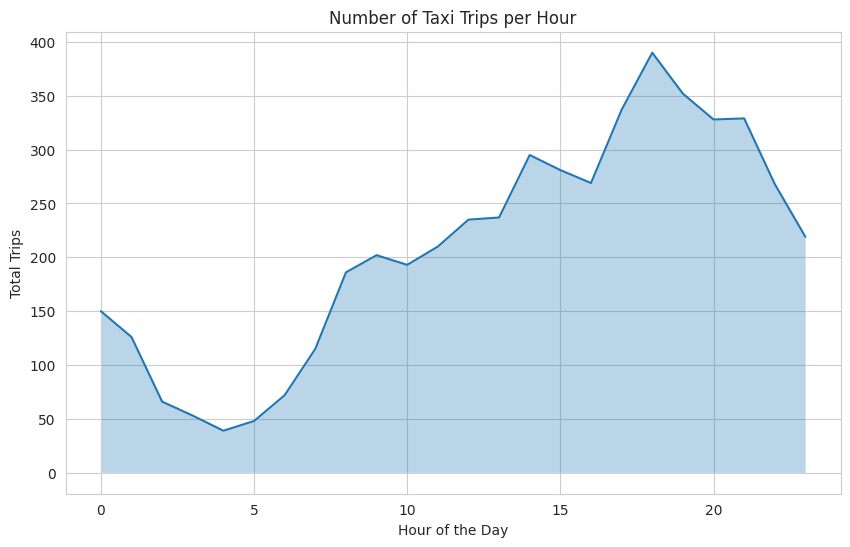

In [6]:
hour_counts = data_cleaned_df.groupby('pickup_hour').size()
plt.figure(figsize=(10,6))
sns.lineplot(x=hour_counts.index, y=hour_counts.values)
plt.fill_between(hour_counts.index, hour_counts.values, alpha=0.3)
plt.title('Number of Taxi Trips per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Trips')
plt.show()

*Description*:
Peak taxi activity occurs between 8–10 AM and 5–8 PM, reflecting typical commute hours in NYC.
Early morning (0–5 AM) sees the lowest number of trips, indicating minimal demand during late night hours.
Midday (11 AM–4 PM) has moderate trip activity, possibly linked to lunch breaks and errands.

*Insight*: Taxi services follow predictable urban mobility patterns, peaking during rush hours.

### 8.2 Average fare per borough

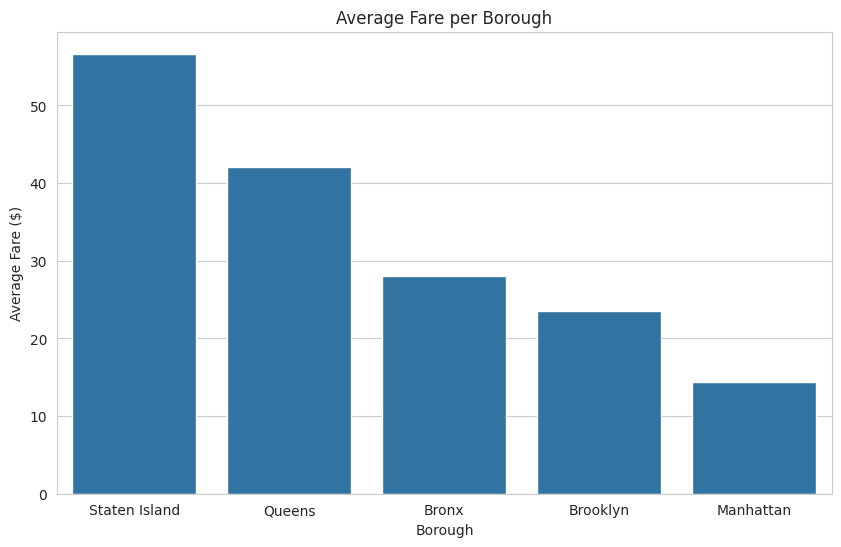

In [7]:
fare_df = data_zones_df.groupby('pu_borough')['fare_amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=fare_df.index, y=fare_df.values)
plt.title('Average Fare per Borough')
plt.xlabel('Borough')
plt.ylabel('Average Fare ($)')
plt.show()

*Description*:
Staten Island shows the highest average fare, likely due to longer trips, higher congestion, and premium service areas.
Boroughs like Bronx, Queens, Brooklyn ad Manhattan have lower average fares, reflecting shorter trips or lower trip density.

*Insight*: Higher average fares in Staten Island reflect long-distance, lower-density travel, while Manhattan and other boroughs have more frequent short trips, highlighting how fare values are influenced by trip length and urban density rather than total revenue.

### 8.3 Map of taxi pickups by zone

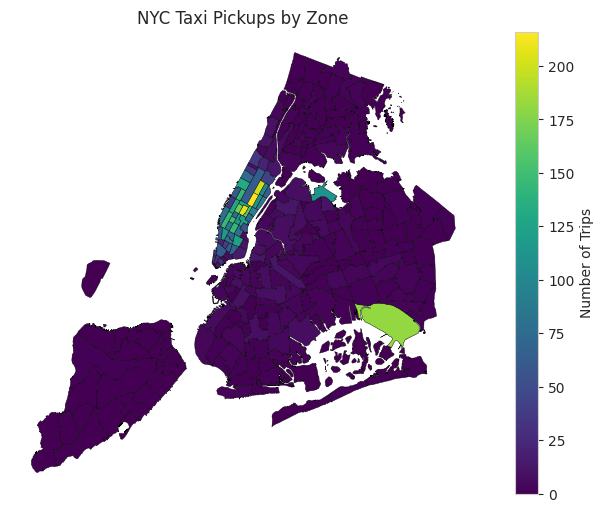

In [8]:
pickup_map = data_zones_df.groupby('pu_zone').size().reset_index(name='total_trips')
map_df = zones_gdf.merge(pickup_map, left_on='zone', right_on='pu_zone', how='left')
map_df['total_trips'] = map_df['total_trips'].fillna(0)

fig, ax = plt.subplots(figsize=(10,6))
map_df.plot(column='total_trips', cmap='viridis', linewidth=0.3, edgecolor='black', legend=True,
            legend_kwds={'label':'Number of Trips','orientation':'vertical'}, ax=ax)
ax.set_title('NYC Taxi Pickups by Zone')
ax.axis('off')
plt.show()

*Description*:
The map shows the total number of taxi pickups per zone across New York City.
Manhattan has the highest number of pickups, particularly in central business and tourist areas, reflecting its role as the main hub for work, tourism, and transport.
Outer boroughs such as Brooklyn, Queens, Bronx, and Staten Island have significantly fewer pickups, with some zones showing very low activity.
The spatial pattern is highly uneven, highlighting areas with concentrated taxi demand.

*Insight*: Taxi demand is strongly concentrated in Manhattan, indicating that drivers and fleet services should focus on these high-demand zones, especially during peak hours. Mapping pickups by zone helps identify hotspots and can support fleet allocation and urban mobility planning.

### 8.4 Number of Taxi Trips by Payment Type

/tmp/ipykernel_17/3246199943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')


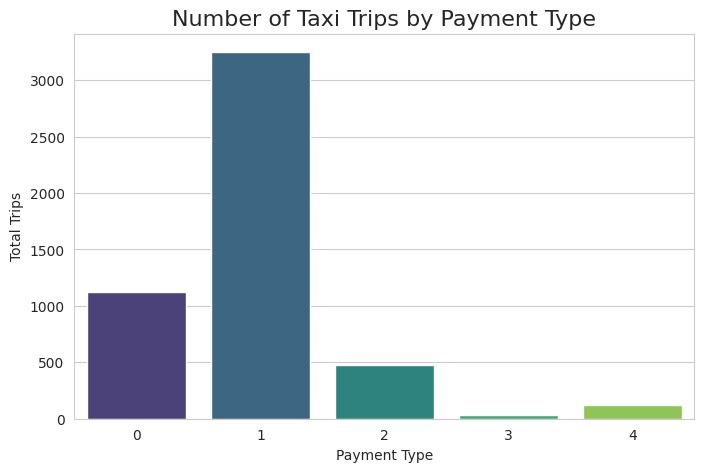

In [9]:
payment_counts = data_zones_df['payment_type'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Number of Taxi Trips by Payment Type', fontsize=16)
plt.xlabel('Payment Type')
plt.ylabel('Total Trips')
plt.show()

*Description*:
The graph shows that one or two payment types dominate, with others being rare. Understanding this helps drivers, fleet managers, and policymakers to adapt services and improve payment convenience.

*Insight*: Most trips still use cash or standard credit cards, reflecting common passenger preferences, and interesting trends toward digital or alternative payment methods can also be observed.

# 9. Detailed Conclusions

Based on the exploratory data analysis and visualizations, several important insights about taxi trips in New York City in March 2025 can be drawn:

### 1. Temporal Patterns
- **Peak Hours**: The highest number of trips occurs during typical commuting hours, especially between **7-10 AM** and **5-8 PM**, reflecting work-related transportation demand. There is also a noticeable smaller peak around **midnight**, likely related to nightlife and airport trips.
- **Low Activity Hours**: Early morning hours (2-5 AM) have the lowest number of trips, indicating reduced taxi demand during these times.

### 2. Spatial Patterns
- **Borough Activity**: Manhattan consistently shows the highest number of pickups and dropoffs, followed by Brooklyn and Queens. Staten Island and the Bronx have significantly lower activity, consistent with population density and urban mobility patterns.
- **High-Activity Zones**: Certain zones in Manhattan, such as Midtown, Times Square, and areas around major transportation hubs, dominate taxi pickups, reflecting high demand from both commuters and tourists.
- **Low-Activity Zones**: Peripheral neighborhoods and less densely populated areas exhibit fewer trips, suggesting opportunities for ride-hailing services to adjust supply.

### 3. Trip Distance and Fare Patterns
- **Average Trip Distance**: Trips originating in Manhattan tend to be shorter on average, reflecting dense urban travel, whereas trips starting in outer boroughs (Queens, Brooklyn) often cover longer distances.
- **Fare Patterns**: Average fares are higher in Manhattan, not only due to demand but also because of shorter, more frequent trips that can accumulate more tips. Outer boroughs tend to have lower average fares per trip but cover longer distances, reflecting different travel patterns.

### 4. Popular Routes
- **Top Routes**: The most frequent routes are within Manhattan or from Manhattan to major airports (JFK, LaGuardia). This indicates that Manhattan is the main origin and destination hub for taxi activity.
- **Inter-Borough Flows**: There is a noticeable volume of trips between Manhattan and Brooklyn/Queens, highlighting commuter flows and connections to residential areas.

### 5. Insights for Urban Mobility
- **Demand Forecasting**: Identifying peak hours and high-demand zones can inform taxi fleet management and optimize driver allocation.
- **Urban Planning**: Understanding which zones generate the most trips can help city planners improve public transportation infrastructure and manage congestion.
- **Service Strategy**: Taxi companies and ride-hailing platforms could target areas with high demand but limited availability, especially during off-peak hours or in outer boroughs.

**Overall**, this analysis reveals clear spatial and temporal patterns in NYC taxi trips, highlights the concentration of trips in Manhattan, and provides actionable insights for transportation planning, fleet management, and urban mobility optimization.